In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=Warning)

We can copy the directory to kaggle/working (because kaggle/input is available only for reading):

In [3]:
%cp -r /kaggle/input/how-machine-sees/dataset_CV_bootcamp /kaggle/working

# 1. First look at the data

Let's take a look at a random image and a label (they have the same names):

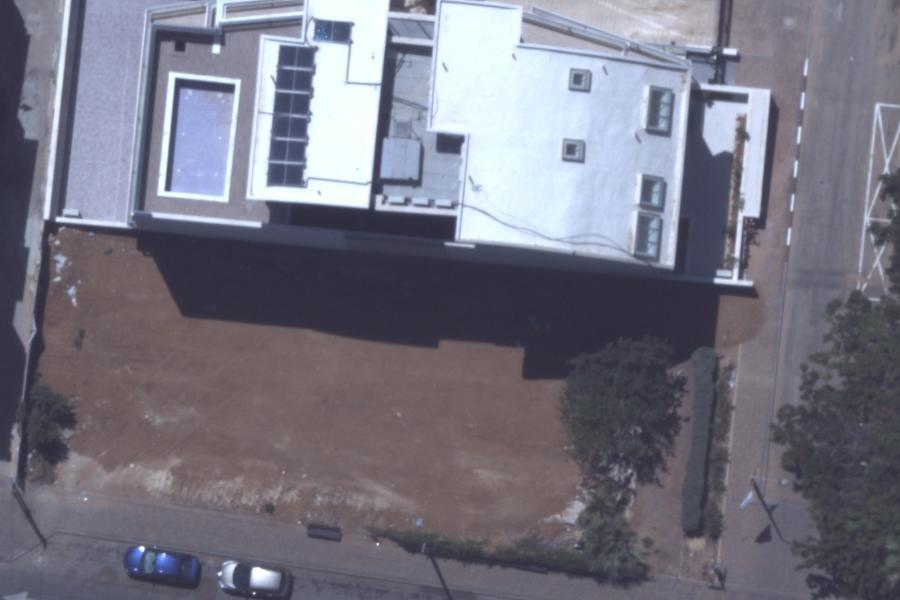

In [4]:
# we use cv2_imshow() from google.colab, because cv2.imshow() leads to kernes restarting
img_path = '/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/train/images/487d66fd-0730-41ea-a658-287c7dbdb42e.jpg'
img = cv2.imread(img_path)

cv2_imshow(img)

In [5]:
label_path = '/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/train/labels/487d66fd-0730-41ea-a658-287c7dbdb42e.txt'
with open(label_path) as f:
    print(f.read())

1 0.0003111111111111111 0.0015999999999999999 0.00009999999999999999 0.00011666666666666668
1 0.17888888888888888 0.9416666666666667 0.08888888888888889 0.06666666666666667
1 0.2828 0.9661500000000001 0.08455555555555555 0.06771666666666668



# 2. Data verification and EDA

In [6]:
images_path = '/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/train/images'
labels_path = '/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/train/labels'

**2.1 Damaged files**

We need to check that the frames are defined correctly in the files (during model training, it is specified that box and segment counts should be equal). All annotation files should have the same structure, either using rectangles or polygons (rectangles in our case), throughout your dataset. Mixing different annotation structures within the same dataset can cause issues during training.

In [7]:
damaged_files = set()

for filename in os.listdir(labels_path):
    path = os.path.join(labels_path, filename)
    with open(path) as f:
        rows = f.readlines()
        for row in rows:
            row = row.strip().split()
            # we need to check the number of points and class numbers
            if len(row) != 5 or row[0] not in ('0', '1', '2'):
                damaged_files.add(filename)
                break

damaged_files

{'1c8cc719-9cd4-4f47-9702-3927aaf3e394.txt',
 '283e2c3d-7c40-4cc4-81bb-468cb6f1fa8b.txt',
 '46c5c65a-0f85-42d8-91be-f1f7860697a0.txt',
 '6135ecf0-71b0-4336-b60e-d9b2882b0d74.txt',
 '674fc3d3-ca99-4b9b-92bc-75d19d80b8a0.txt',
 '8e331a2c-197e-4d22-bdcc-1c764f9b6274.txt',
 '93de7c42-d5d9-40d5-bc33-0feee449b0da.txt',
 'a1e51571-2d94-47e9-b3d5-0ae4de73178d.txt',
 'a624cb32-ab34-4cef-868e-1b0c0f819312.txt',
 'ae28b163-f900-492c-8d25-e56f9f2d20a3.txt',
 'bf610403-9bbb-4cb8-afa4-1cdc22d61768.txt',
 'ced0b6e6-31c6-49e9-84fa-1fe743291f11.txt',
 'e34fd51f-c652-4e72-9bbc-b3931dc7a582.txt',
 'ee49a8ce-b9db-428f-8a80-8694e54cbbef.txt',
 'f80dd75d-9714-47bf-9666-5618f594a1da.txt'}

We can remove damaged files:

In [8]:
# number of files initially
print(len(os.listdir(images_path)))
print(len(os.listdir(labels_path)))

3708
3708


In [9]:
for filename in damaged_files:
    os.remove(os.path.join(images_path, filename[:-3] + 'jpg'))
    os.remove(os.path.join(labels_path, filename))

print(len(os.listdir(images_path)))
print(len(os.listdir(labels_path)))         

3693
3693


**2.2 The balance of classes**

We need to check the balance of classes:

In [10]:
def balance_of_classes_check(labels_path):
    # a dict with the number of images for each class
    classes = {}
    # a dict with the filenames for each class
    classes_files = {}
    
    labels = os.listdir(labels_path)
    for i in labels:
        with open(os.path.join(labels_path, i)) as f:
            for s in f.readlines():
                cl = int(s[0])
                classes[cl] = classes.get(cl, 0) + 1
                # we need unique file names
                classes_files.setdefault(cl, set()).add(i[:-3] + 'jpg')

    # converting a set to a list
    for k in classes_files:
        classes_files[k] = list(classes_files[k])

    return classes, classes_files


classes, classes_files = balance_of_classes_check(labels_path)
print(classes)
# number of unique images for each class
print({k: len(v) for k, v in classes_files.items()})

{2: 1693, 1: 11496, 0: 4137}
{2: 877, 1: 1854, 0: 927}


We see that the number of class 2 objects (ships) is significantly smaller than the rest.

It is desirable to make the classes balanced, this is possible with the help of oversampling.

**2.3 Image sizes**

We can also check the size of images:

In [11]:
sizes = {}
images = os.listdir(images_path)
# we use sampling
for i in random.sample(images, 2000):
    img = cv2.imread(os.path.join(images_path, i))
    shape = img.shape
    sizes[shape] = sizes.get(shape, 0) + 1

sizes

{(768, 768, 3): 539,
 (1080, 1920, 3): 79,
 (640, 1137, 3): 693,
 (750, 1846, 3): 31,
 (640, 640, 3): 138,
 (1500, 1845, 3): 21,
 (416, 416, 3): 253,
 (600, 900, 3): 117,
 (540, 1024, 3): 31,
 (750, 1845, 3): 24,
 (512, 512, 3): 22,
 (720, 1280, 3): 4,
 (1585, 2047, 3): 3,
 (80, 80, 3): 25,
 (1570, 2047, 3): 3,
 (740, 1667, 3): 1,
 (1522, 2048, 3): 3,
 (1578, 2047, 3): 1,
 (1024, 1024, 3): 5,
 (1519, 2048, 3): 1,
 (639, 1542, 3): 1,
 (765, 625, 3): 1,
 (1532, 2048, 3): 2,
 (648, 1404, 3): 1,
 (368, 956, 3): 1}

Image sizes vary.

**2.4 Oversampling**

In [12]:
import shutil
from pathlib import Path

def oversample_rare_classes(images_path, labels_path):    
    # we add 1500 images of class 2 (ships) with repetitions
    copies = random.choices(classes_files[2], k=1500)

    for idx, filename in enumerate(copies):
        # copy an image
        # Path returns a PosixPath object
        src_img = Path(images_path) / f'{filename}'
        dst_img = Path(images_path) / f'{filename[:-4]}_dup{idx}.jpg'
        # src (source) - path of the file being copied
        # dst (destination) - path of the new file        
        shutil.copy(src_img, dst_img)

        # copy a label
        src_lbl = Path(labels_path) / f'{filename[:-4]}.txt'
        dst_lbl = Path(labels_path) / f'{filename[:-4]}_dup{idx}.txt'
        shutil.copy(src_lbl, dst_lbl)
    

oversample_rare_classes(images_path, labels_path)

In [13]:
classes, classes_files = balance_of_classes_check(labels_path)
print(classes)
print({k: len(v) for k, v in classes_files.items()})

{2: 4581, 1: 11496, 0: 4137}
{2: 2377, 1: 1854, 0: 927}


**2.5 Validation sample**

Now let's create a directory for the validation sample:

In [14]:
%mkdir /kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation
%mkdir /kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation/images
%mkdir /kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation/labels

Let's check at the new directory structure:

In [15]:
for dirpath, dirnames, filenames in os.walk('/kaggle/working'):
    print(dirpath)

/kaggle/working
/kaggle/working/dataset_CV_bootcamp
/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp
/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation
/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation/images
/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation/labels
/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/test
/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/test/images
/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/train
/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/train/images
/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/train/labels
/kaggle/working/.virtual_documents


Let's move 10% images and labels to the new directory:

In [16]:
images_names = os.listdir(images_path)
num_images = len(images_names)
print(f'The original train contains {num_images} images')

validation_images_names = random.sample(images_names, num_images // 10)
for val_img in validation_images_names:
    os.rename(f'/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/train/images/{val_img}',
              f'/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation/images/{val_img}')
    os.rename(f'/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/train/labels/{val_img[:-4]}.txt',
              f'/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation/labels/{val_img[:-4]}.txt')

print(f'The validation sample contains {len(os.listdir("/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation/images/"))} images')
print(f'The new train contains {len(os.listdir(images_path))} images')

The original train contains 5193 images
The validation sample contains 519 images
The new train contains 4674 images


Let's look at the data.yaml file and complete it:

In [17]:
%cat /kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/data.yaml

# Paths to training and validation image directories
train: /path/to/train/here

# Number of classes
nc: 3

# Class names
names: ['plane', 'car', 'ship']

In [18]:
%%writefile /kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/data.yaml
# Paths to training and validation image directories
train: train/images
val: validation/images

# Number of classes
nc: 3

# Class names
names: ['plane', 'car', 'ship']

Overwriting /kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/data.yaml


In [19]:
%cat /kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/data.yaml

# Paths to training and validation image directories
train: train/images
val: validation/images

# Number of classes
nc: 3

# Class names
names: ['plane', 'car', 'ship']


# 3. Baseline

We will use YOLOv3 model at first.

In [ ]:
pip install ultralytics

In [ ]:
from ultralytics import YOLO

# load a pretrained model
model = YOLO('yolov3.pt')

# model = YOLO("path/to/last.pt") # load a partially trained model

# patience=5 - early stopping (5 epochs without metric improvement)
# batch=-1 - automatic batch size selection
# device=0 - using GPU
results = model.train(data='/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/data.yaml',
                      epochs=100, patience=5, batch=-1, save=True, device=0, optimizer='auto',
                      verbose=True)

Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 35, best model saved as best.pt.

We trained our model and saved it to load it later.

In [21]:
from ultralytics import YOLO

model = YOLO('/kaggle/input/yolov3-trained/pytorch/default/1/best.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


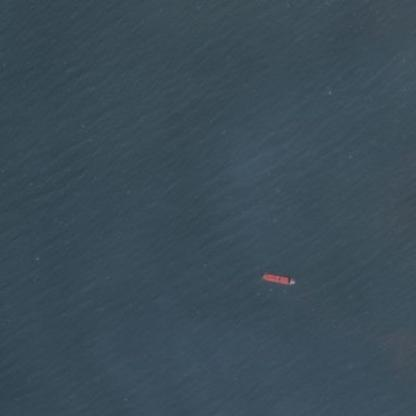

In [22]:
# let's take a random image from train
img_name = os.listdir('/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation/images')[20]
path = os.path.join('/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation/images', img_name)
img = cv2.imread(path)

cv2_imshow(img)


image 1/1 /kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation/images/292d5164-76bd-41b6-96ad-e115d02dd405_dup847.jpg: 640x640 1 ship, 37.1ms
Speed: 6.5ms preprocess, 37.1ms inference, 22.8ms postprocess per image at shape (1, 3, 640, 640)
tensor([[0.6684, 0.6693, 0.0924, 0.0429]], device='cuda:0')
tensor([2.], device='cuda:0')


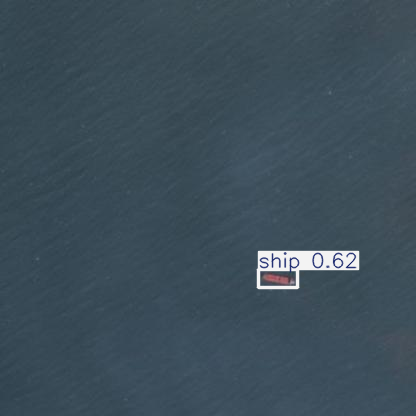

In [23]:
# run inference on the source
results = model(path) # list of Results objects

# results - is a list
for result in results:
    # result - is a special class from ultralytics library
    boxes = result.boxes # Boxes object for bounding box outputs
    print(boxes.xywhn) # Boxes in requested format
    print(boxes.cls) # Classes of boxes
    result.show() # display to screen
    # result.save(filename='result.jpg') # save to disk

In [25]:
import glob

def create_df_res(model):
    test_images_path_prefix = '/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/test/images/'
    # search for files with names matching a pattern (we get paths)
    test_images_names = glob.glob(test_images_path_prefix + '*.jpg')

    df = pd.DataFrame(columns=["image", "class_id", "center_x", "center_y",
                               "width", "height"])
    all_res = []

    for i in test_images_names:
        results = model(i, verbose=False)
        all_res.append(results)

    for j, results in enumerate(all_res):
        for i in range(len(results)):
            boxes = results[i].boxes
            xywhn = boxes.xywhn.cpu()
            cls = boxes.cls.cpu()
            img_name = test_images_names[j]
            for idx in range(len(boxes)):
                submission_info = [img_name.split('/')[-1]] + [int(cls[idx])] + xywhn[idx].tolist()
                df.loc[len(df)] = submission_info
    
            if len(boxes) == 0:
                submission_info = [img_name.split("/")[-1], None, None, None, None, None]
                df.loc[len(df)] = submission_info

    return df

In [ ]:
df = create_df_res(model)

df

In [ ]:
df.to_csv('submission.csv', index=False)

We need to convert our csv-file into a specific format:

In [26]:
import csv
import json
from collections import defaultdict

def convert_csv():
    # we specify the actual path to our submission file
    input_csv = '/kaggle/working/submission.csv'
    output_csv = 'converted.csv'
    
    data = defaultdict(list)
    
    with open(input_csv, newline='') as csvfile:
        reader = csv.DictReader(csvfile, delimiter=',')
        for row in reader:
            image = row['image']
            bbox = str(row['class_id']) + ' '+ str(row['center_x']) + ' ' + str(row['center_y']) + \
                       ' ' + str(row['width']) + ' ' + str(row['height'])
            data[image].append(bbox)
    
    with open(output_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['id', 'label'])
        for image, bboxes in data.items():
            result_json = json.dumps(bboxes, separators=('\t', '\n'))
            writer.writerow([image, result_json])

Score 0.46091 private, 0.49506 public

# 4. ML and scoring

Now we can use the relevant YOLO26 model and tune the hyperparameters.

We can use the build-in tune() method, but Optuna provides more flexibility.

In [ ]:
from ultralytics import YOLO
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import torch

# # define search space
# search_space = {'lr0': (0.001, 0.3), 'lrf': (0.1, 1), 'weight_decay': (0.001, 1),
#                 'box': (0.1, 1), 'cls': (0.2, 2), 'dfl': (0.2, 2),
#                 'degrees': (0, 80)
#                }

# # tune hyperparameters
# model.tune(data='/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/data.yaml',
#            epochs=20, optimizer='Adam', space=search_space, plots=False,
#            save=False, val=False)

def objective(trial):
    params = {'batch': trial.suggest_categorical('batch', [8, 16]),
              'optimizer': trial.suggest_categorical('optimizer', ['SGD', 'AdamW']),
              'lr0': trial.suggest_float('lr0', 1e-4, 0.005, log=True),
              'momentum': trial.suggest_float('momentum', 0.8, 0.98),
              'weight_decay': trial.suggest_float('weight_decay', 0.001, 0.01, log=True),
              # augmentation parameters
              'hsv_h': trial.suggest_float('hsv_h', 0, 0.1),
              'hsv_s': trial.suggest_float('hsv_s', 0, 0.9),
              'hsv_v': trial.suggest_float('hsv_v', 0, 0.9),
              'degrees': trial.suggest_float('degrees', 0, 45), 
              'translate': trial.suggest_float('translate', 0, 0.5),
              'scale': trial.suggest_float('scale', 0, 0.9)
             }

    # YOLO26x is the most accurate, but YOLO26n is the fastest
    model = YOLO('yolo26x.pt')
    # model = YOLO('yolo26n.pt')
    
    try:
        results = model.train(data='/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/data.yaml',
                              epochs=20,
                              patience=4,
                              # with increasing imgsz - more accurate, but slower
                              # must be multiple of max stride 32
                              imgsz=640,
                              # save=True,
                              # save_period=4,
                              cache='disc', # caching for speed
                              device='cuda' if torch.cuda.is_available() else 'cpu',
                              exist_ok=True,
                              pretrained=True,
                              seed=42,
                              verbose=True,
                              close_mosaic=4,
                              amp=True,
                              **params
                             )
        # getting metrics - the documentation states that no arguments are required
        metrics = model.val()
        # our target is mAP50
        map50 = metrics.box.map50
        return map50

    except Exception as e:
        print(f'Error in trial {trial.number}: {e}')


study = optuna.create_study(direction='maximize', study_name='YOLO26', sampler=TPESampler(seed=42),
                            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
                           )
study.optimize(objective, n_trials=20, show_progress_bar=True)

yolo_optuna_score = study.best_value
yolo_optuna_params = study.best_params

In [ ]:
# fig1 = optuna.visualization.plot_optimization_history(study)
# fig2 = optuna.visualization.plot_param_importances(study)
# fig3 = optuna.visualization.plot_parallel_coordinate(study)
    
# fig1.show()
# fig2.show()
# fig3.show()

In [24]:
# best_params = {'batch': 16, 'lr0': 0.002115429079726122, 'momentum': 0.9509594919508108, 'weight_decay': 0.004835952776465951,
#                'hsv_h': 0.05978999788110852, 'hsv_s': 0.8296868115208051, 'hsv_v': 0.07964325184672755, 'degrees': 8.819228808861533,
#                'translate': 0.022613644455269033, 'scale': 0.2927972976869379}

params = {'batch': 8, 'optimizer': 'AdamW', 'lr0': 0.0007790143126276247, 'momentum': 0.8777501033555809, 'weight_decay': 0.001955370866274525,
          'hsv_h': 0.06118528947223795, 'hsv_s': 0.12554447458683765, 'hsv_v': 0.26293018368169635, 'degrees': 16.486282948216125,
          'translate': 0.22803499210851796, 'scale': 0.7066583652537123}

Now we will train our model with optimal hyperparameters:

In [ ]:
model = YOLO('yolo26m.pt')
# model = YOLO('yolo26n.pt')

results = model.train(data='/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/data.yaml',
                      epochs=100,
                      patience=15,
                      # with increasing imgsz - more accurate, but slower
                      # must be multiple of max stride 32
                      imgsz=640,
                      save=True,
                      save_period=10,
                      cache='disc',
                      device='cuda' if torch.cuda.is_available() else 'cpu',
                      exist_ok=True,
                      pretrained=True,
                      seed=42,
                      verbose=True,
                      close_mosaic=20,
                      amp=True,
                      **params
                     )

We trained our model and saved it to load it later.

In [27]:
from ultralytics import YOLO

model = YOLO('/kaggle/input/models/romaneyvazov/yolo26m/pytorch/trained/1/YOLO26m.pt')

Predictions for 6336ea79-58dd-4aca-8b4f-48ecc136f233.jpg


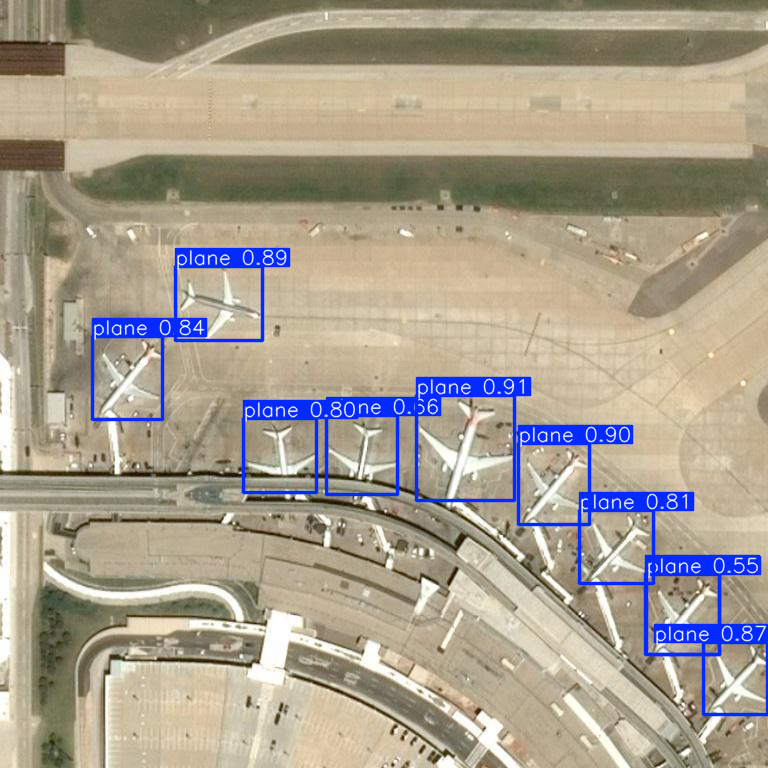


Predictions for eb9905f1-09a1-4b37-bd98-3da7c1351315.jpg


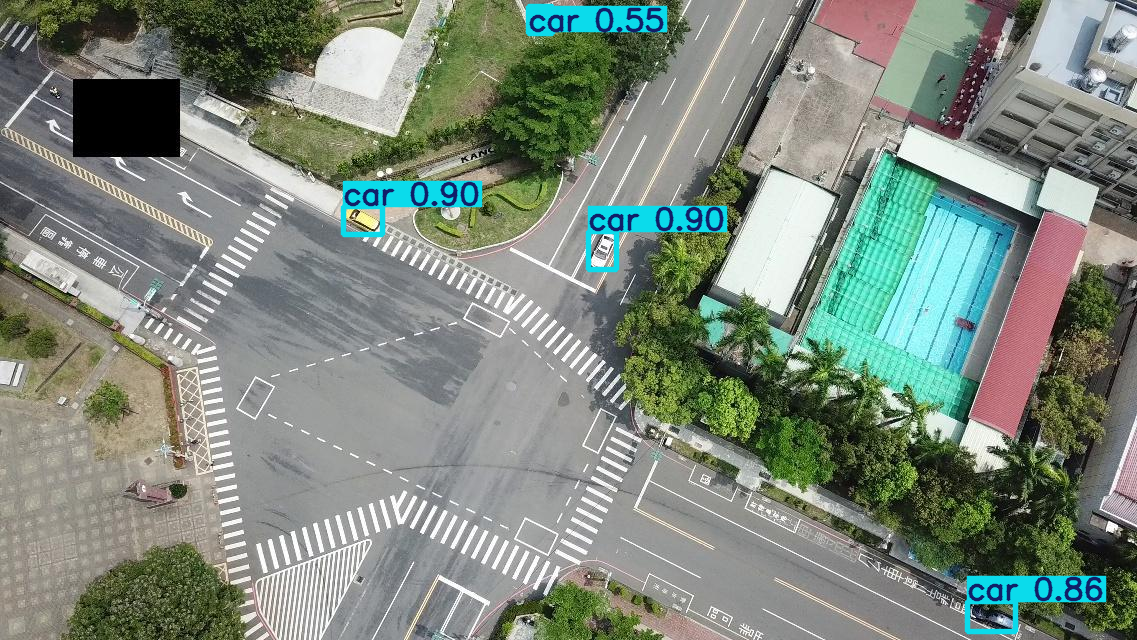


Predictions for e842d00e-7291-406b-af16-1bedb630048e_dup165.jpg


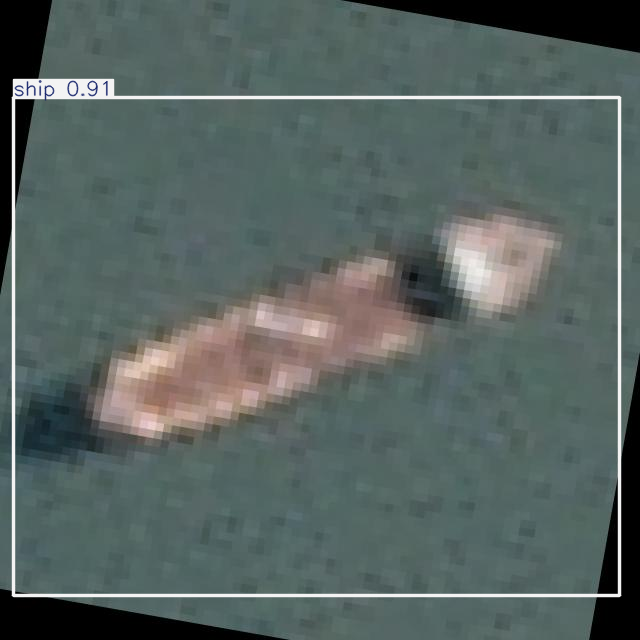


Predictions for 25ffe8c8-ab43-4d63-a1f1-c8059e2f2aca_dup1354.jpg


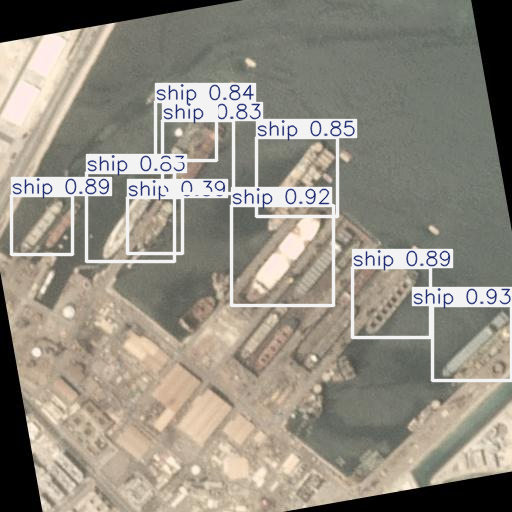


Predictions for 022a721d-f771-4492-9361-6c44eaefe4c7.jpg


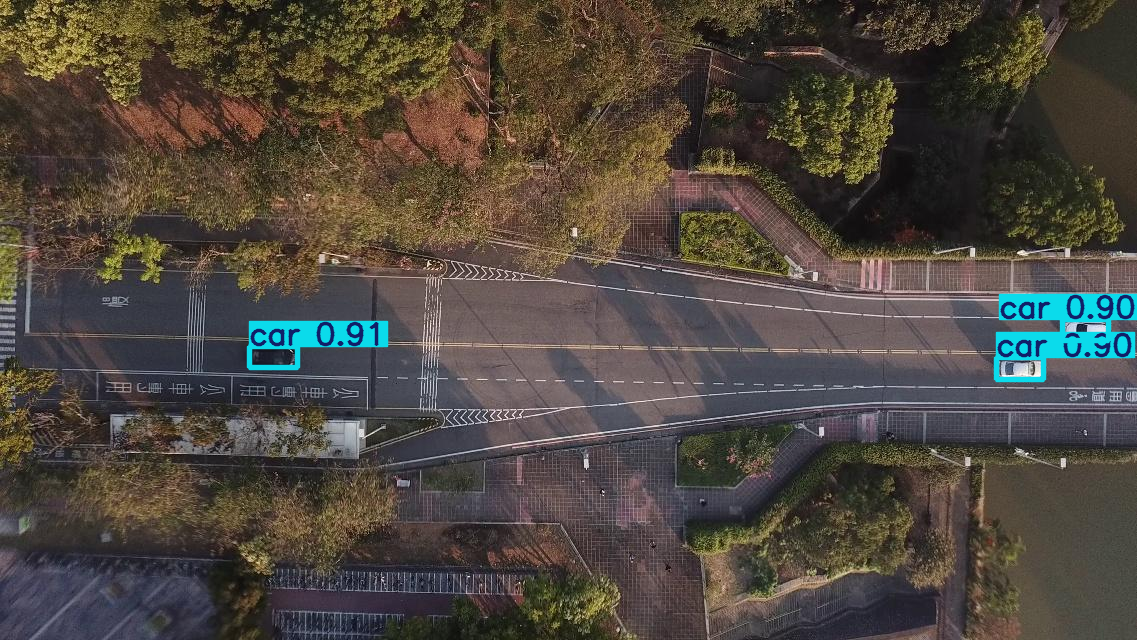

In [28]:
# function for analyzing errors in the validation sample
def analyze_errors(path):
    img_names = os.listdir(path)[:5]
    for img_name in img_names:
        results = model(os.path.join(path, img_name), conf=0.25, verbose=False)

        for result in results:
            print(f'Predictions for {img_name}')
            result.show() # display to screen
            print()


analyze_errors('/kaggle/working/dataset_CV_bootcamp/dataset_CV_bootcamp/validation/images')

In [29]:
df = create_df_res(model)

df

,image,class_id,center_x,center_y,width,height
0,575bc5cf-791e-48e5-a3c9-f74137211e9c.jpg,0,0.580650,0.737489,0.262232,0.226639
1,575bc5cf-791e-48e5-a3c9-f74137211e9c.jpg,0,0.760566,0.497458,0.139060,0.151204
2,575bc5cf-791e-48e5-a3c9-f74137211e9c.jpg,0,0.287960,0.475446,0.137319,0.151118
3,575bc5cf-791e-48e5-a3c9-f74137211e9c.jpg,0,0.181167,0.930901,0.241415,0.137482
4,575bc5cf-791e-48e5-a3c9-f74137211e9c.jpg,0,0.973925,0.208908,0.051646,0.250004
...,...,...,...,...,...,...
5468,584ed823-b38b-4001-a0b5-658081bd4b84.jpg,1,0.230354,0.483804,0.042992,0.037886
5469,584ed823-b38b-4001-a0b5-658081bd4b84.jpg,1,0.330090,0.480959,0.037948,0.034622
5470,584ed823-b38b-4001-a0b5-658081bd4b84.jpg,1,0.458009,0.475001,0.044389,0.033794
5471,584ed823-b38b-4001-a0b5-658081bd4b84.jpg,1,0.282486,0.480714,0.032729,0.032166


In [30]:
df.to_csv('submission.csv', index=False)

In [31]:
convert_csv()

Score 0.56046 private, 0.63097 public - with YOLO26n;

Score 0.58529 private, 0.65104 public - with YOLO26m.